In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.style.use("seaborn-v0_8")


In [ ]:
df = pd.read_csv("/content/playerstats.csv")
df.head()


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,npxG,xA,npxG+xA,xG.1,xA.1,xG+xA,npxG.1,npxG+xA.1,Matches,-9999
0,1,Luis Abram,pe PER,DF,Granada,25.0,1996.0,8,6,560,...,0.5,0.0,0.5,0.08,0.00,0.08,0.08,0.08,Matches,1f462f95
1,2,Marcos Acuña,ar ARG,DF,Sevilla,29.0,1991.0,31,26,2260,...,1.4,3.0,4.4,0.06,0.12,0.18,0.06,0.18,Matches,81442ecb
2,3,Martin Agirregabiria,es ESP,DF,Alavés,25.0,1996.0,24,17,1616,...,0.2,1.0,1.2,0.01,0.05,0.07,0.01,0.07,Matches,355c883a
3,4,Julen Agirrezabala,es ESP,GK,Athletic Club,20.0,2000.0,4,4,360,...,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,Matches,a2c1a8d3
4,5,Sergio Agüero,ar ARG,FW,Barcelona,33.0,1988.0,4,2,151,...,1.1,0.3,1.3,0.64,0.16,0.80,0.64,0.80,Matches,4d034881


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()


Shape: (617, 34)

Columns:
Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', 'MP', 'Starts',
       'Min', '90s', 'Gls', 'Ast', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR',
       'Gls.1', 'Ast.1', 'G+A', 'G-PK.1', 'G+A-PK', 'xG', 'npxG', 'xA',
       'npxG+xA', 'xG.1', 'xA.1', 'xG+xA', 'npxG.1', 'npxG+xA.1', 'Matches',
       '-9999'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rk         617 non-null    int64  
 1   Player     617 non-null    object 
 2   Nation     616 non-null    object 
 3   Pos        617 non-null    object 
 4   Squad      617 non-null    object 
 5   Age        616 non-null    float64
 6   Born       616 non-null    float64
 7   MP         617 non-null    int64  
 8   Starts     617 non-null    int64  
 9   Min        617 non-null    int64  
 10  90s        617 non-null    float64
 11  G

In [ ]:
X = df[["Age"]][0:20]       # Feature
y = df["Min"][0:20]          # Target

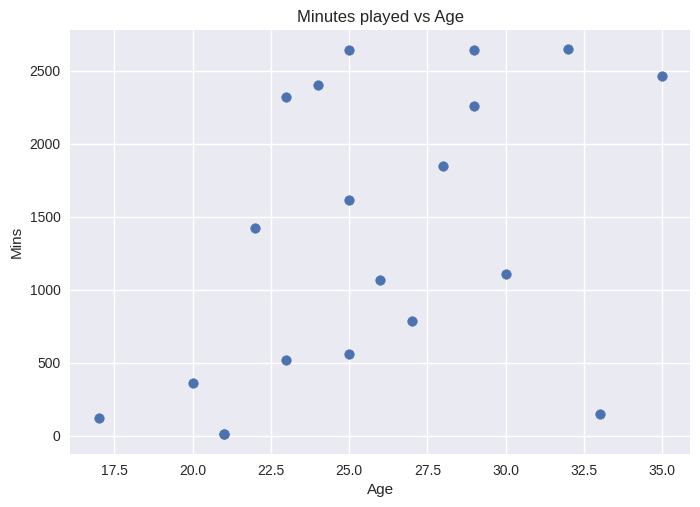

In [ ]:
plt.figure()
plt.scatter(X, y)
plt.xlabel("Age")
plt.ylabel("Mins")
plt.title("Minutes played vs Age")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

Intercept (b0): -1292.0543567781256
Slope (b1): 105.26140668753088


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Root Mean Squared Error: {rmse:.2f}")

Root Mean Squared Error: 628.50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


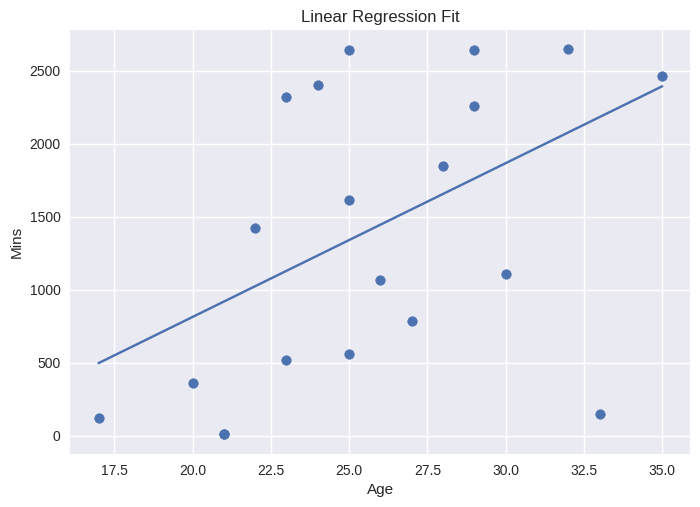

In [ ]:
X_sorted = np.sort(X.values, axis=0)
y_line = model.predict(X_sorted)

plt.figure()
plt.scatter(X, y)
plt.plot(X_sorted, y_line)
plt.xlabel("Age")
plt.ylabel("Mins")
plt.title("Linear Regression Fit")
plt.show()


In [ ]:
df["age_squared"] = df["Age"]**2

In [ ]:
df_n=df[0:20]

In [ ]:
X = df_n[["Age", "age_squared"]]
y = df_n["Min"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
b0 = model.intercept_
b1 = model.coef_[0]
b2 = model.coef_[1]

print("Intercept:", b0)
print("Age coefficient:", b1)
print("Age² coefficient:", b2)


Intercept: -10300.153906534064
Age coefficient: 814.2537680248493
Age² coefficient: -13.452385809944401


In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Test RMSE:", rmse)

Test RMSE: 805.7088713700759


In [ ]:
print(y_pred.mean())

1861.2853056865729


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


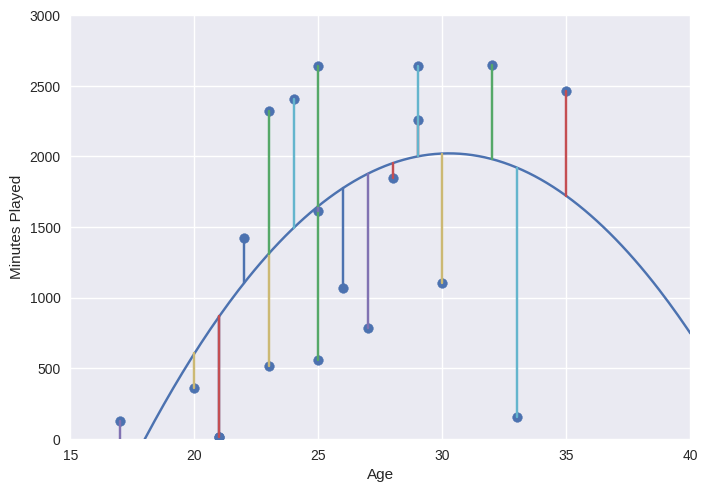

In [ ]:
# Predict on ALL data
X_all = df_n[["Age", "age_squared"]]
y_all = df_n["Min"]

y_all_pred = model.predict(X_all)

# Smooth curve for plotting
age_range = np.linspace(15, 40, 200)
age_range_sq = age_range**2
X_curve = np.column_stack((age_range, age_range_sq))
y_curve = model.predict(X_curve)

fig, ax = plt.subplots()

# Plot original data
ax.scatter(df_n["Age"], df_n["Min"])

# Plot fitted quadratic curve
ax.plot(age_range, y_curve)

# Plot residual lines for ALL data
for i in range(len(df_n)):
    age_val = df_n.iloc[i]["Age"]
    actual = y_all.iloc[i]
    predicted = y_all_pred[i]

    ax.plot([age_val, age_val], [actual, predicted])

ax.set_xlabel("Age")
ax.set_ylabel("Minutes Played")

ax.set_xlim(15, 40)
ax.set_ylim(0, 3000)

plt.show()


# xG model

In [ ]:
!pip install mplsoccer statsbombpy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
from mplsoccer import Pitch, Sbopen, VerticalPitch
from statsbombpy import sb

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, roc_curve

plt.style.use("seaborn-v0_8")


Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Class  Materials/Spring 26/490 D/WyScout/events/events_England.json"

with open(base_path) as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175


In [ ]:
shots = df.loc[df['subEventName'] == 'Shot']
#get shot coordinates as separate columns
shots["X"] = shots.positions.apply(lambda cell: (100 - cell[0]['x']) * 105/100)
shots["Y"] = shots.positions.apply(lambda cell: cell[0]['y'] * 68/100)
shots["C"] = shots.positions.apply(lambda cell: abs(cell[0]['y'] - 50) * 68/100)
#calculate distance and angle
shots["Distance"] = np.sqrt(shots["X"]**2 + shots["C"]**2)
shots["Angle"] = np.where(np.arctan(7.32 * shots["X"] / (shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)) > 0, np.arctan(7.32 * shots["X"] /(shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)), np.arctan(7.32 * shots["X"] /(shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)) + np.pi)
#if you ever encounter problems (like you have seen that model treats 0 as 1 and 1 as 0) while modelling - change the dependant variable to object
shots["Goal"] = shots.tags.apply(lambda x: 1 if {'id':101} in x else 0)

/tmp/ipython-input-2967274061.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots["X"] = shots.positions.apply(lambda cell: (100 - cell[0]['x']) * 105/100)
/tmp/ipython-input-2967274061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots["Y"] = shots.positions.apply(lambda cell: cell[0]['y'] * 68/100)
/tmp/ipython-input-2967274061.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

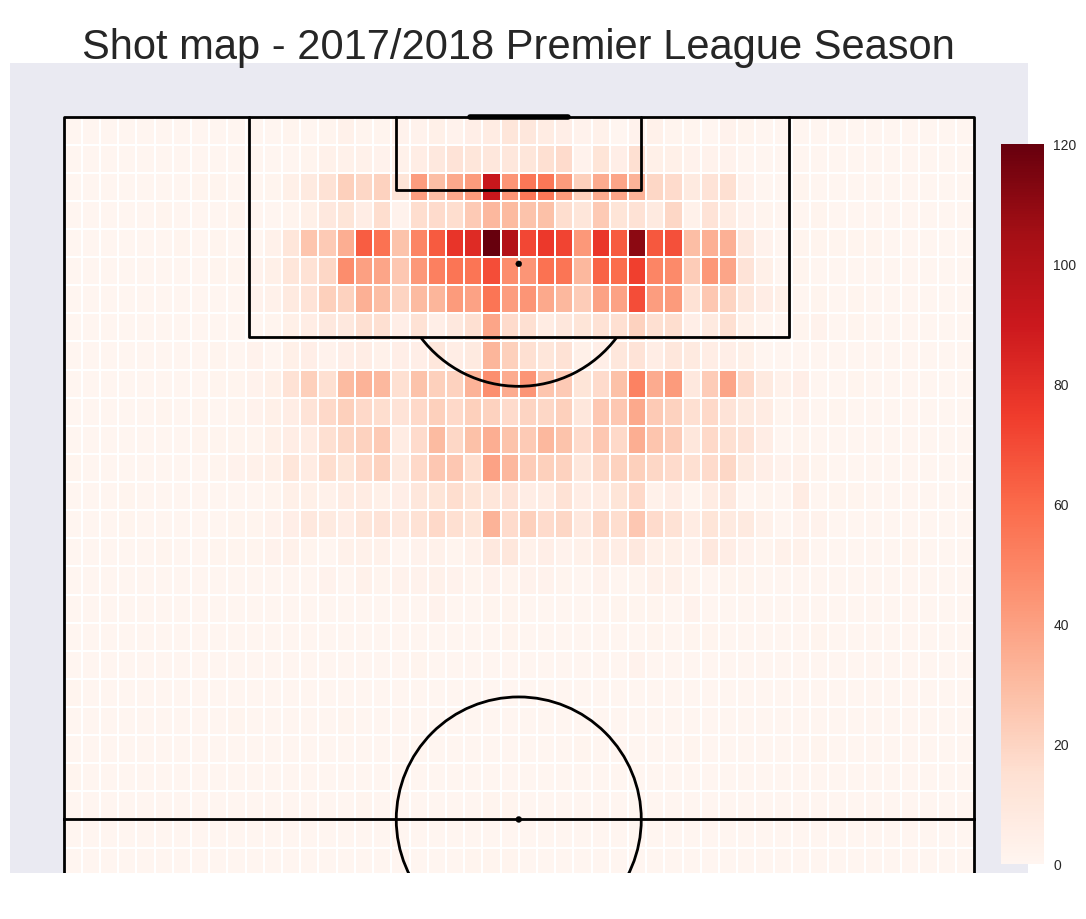

In [ ]:
pitch = VerticalPitch(line_color='black', half = True, pitch_type='custom', pitch_length=105, pitch_width=68, line_zorder = 2)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#subtracting x from 105 but not y from 68 because of inverted Wyscout axis
#calculate number of shots in each bin
bin_statistic_shots = pitch.bin_statistic(105 - shots.X, shots.Y, bins=50)
#make heatmap
pcm = pitch.heatmap(bin_statistic_shots, ax=ax["pitch"], cmap='Reds', edgecolor='white', linewidth = 0.01)
#make legend
ax_cbar = fig.add_axes((0.95, 0.05, 0.04, 0.8))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Shot map - 2017/2018 Premier League Season' , fontsize = 30)
plt.show()

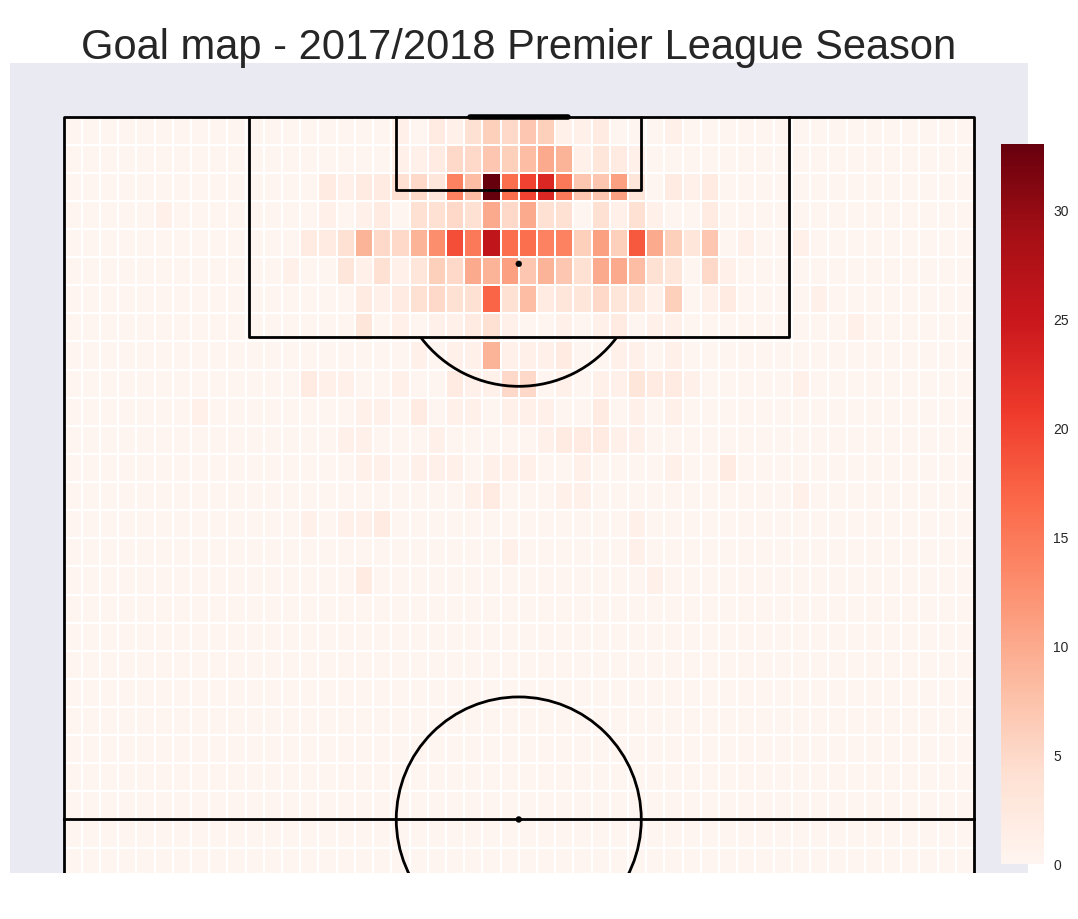

In [ ]:
#take only goals
goals = shots.loc[shots["Goal"] == 1]
#plot pitch
pitch = VerticalPitch(line_color='black', half = True, pitch_type='custom', pitch_length=105, pitch_width=68, line_zorder = 2)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#calculate number of goals in each bin
bin_statistic_goals = pitch.bin_statistic(105 - goals.X, goals.Y, bins=50)
#plot heatmap
pcm = pitch.heatmap(bin_statistic_goals, ax=ax["pitch"], cmap='Reds', edgecolor='white')
#make legend
ax_cbar = fig.add_axes((0.95, 0.05, 0.04, 0.8))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Goal map - 2017/2018 Premier League Season' , fontsize = 30)
plt.show()

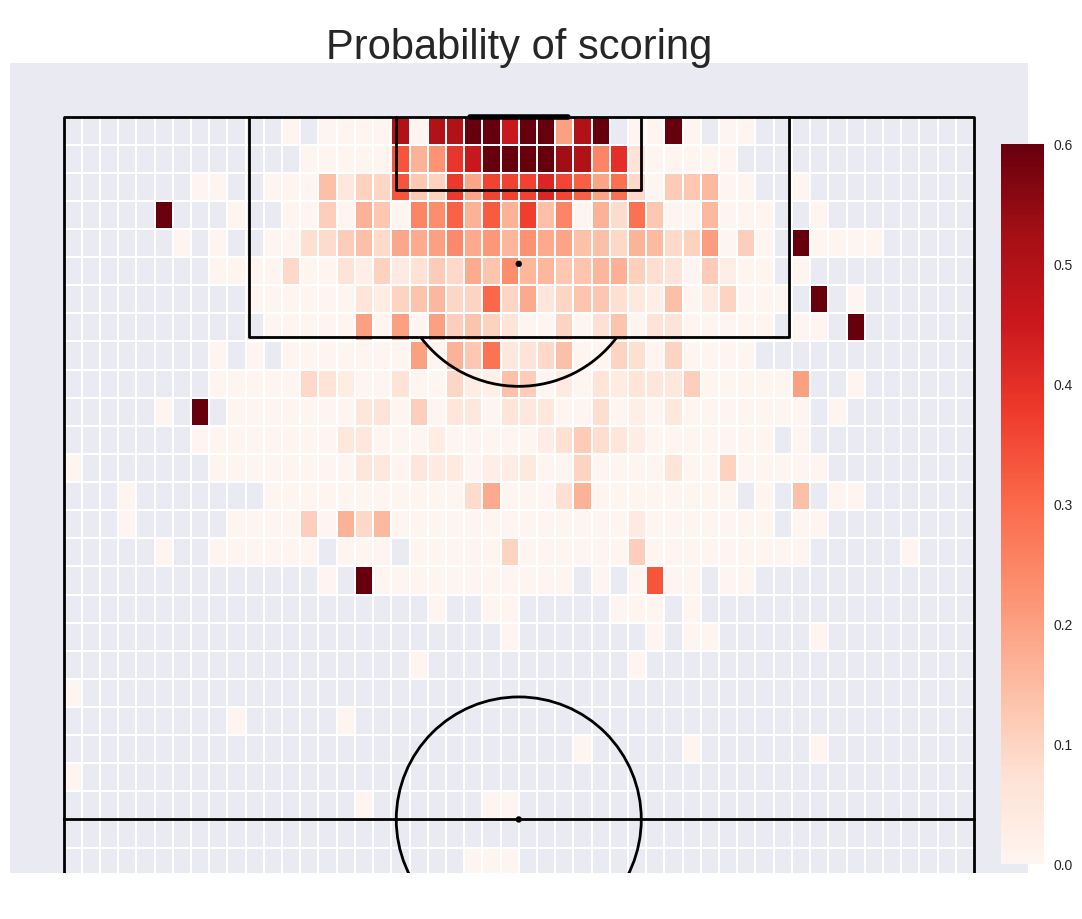

In [ ]:
#plot pitch
pitch = VerticalPitch(line_color='black', half = True, pitch_type='custom', pitch_length=105, pitch_width=68, line_zorder = 2)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
bin_statistic = pitch.bin_statistic(105 - shots.X, shots.Y, bins = 50)
#normalize number of goals by number of shots
bin_statistic["statistic"] = bin_statistic_goals["statistic"]/bin_statistic["statistic"]
#plot heatmap
pcm = pitch.heatmap(bin_statistic, ax=ax["pitch"], cmap='Reds', edgecolor='white', vmin = 0, vmax = 0.6)
#make legend
ax_cbar = fig.add_axes((0.95, 0.05, 0.04, 0.8))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Probability of scoring' , fontsize = 30)
plt.show()

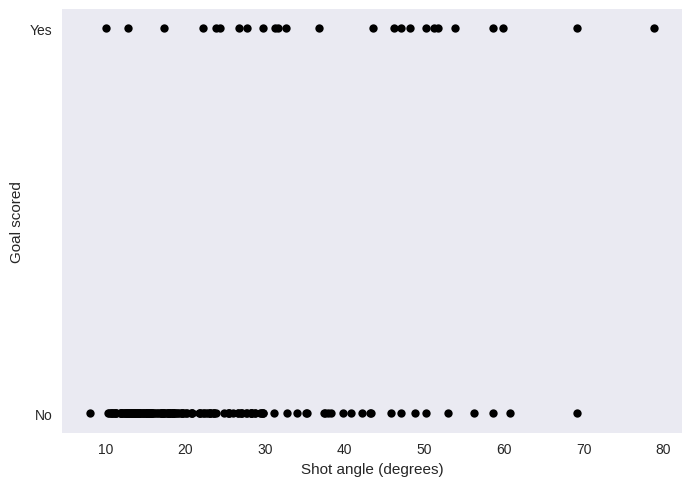

In [ ]:
#first 200 shots
shots_200=shots.iloc[:200]
#plot first 200 shots goal angle
fig, ax = plt.subplots()
ax.plot(shots_200['Angle']*180/np.pi, shots_200['Goal'], linestyle='none', marker= '.', markersize= 12, color='black')
#make legend
ax.set_ylabel('Goal scored')
ax.set_xlabel("Shot angle (degrees)")
plt.ylim((-0.05,1.05))
ax.set_yticks([0,1])
ax.set_yticklabels(['No','Yes'])
plt.grid(False)
plt.show()

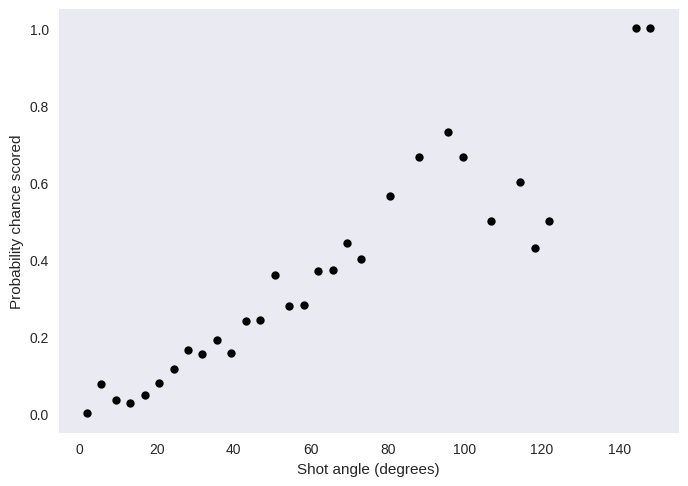

In [ ]:
#number of shots from angle
shotcount_dist = np.histogram(shots['Angle']*180/np.pi, bins=40, range=[0, 150])
#number of goals from angle
goalcount_dist = np.histogram(goals['Angle']*180/np.pi, bins=40, range=[0, 150])
np.seterr(divide='ignore', invalid='ignore') #Ignore divide by 0
#probability of scoring goal
prob_goal = np.divide(goalcount_dist[0], shotcount_dist[0])
angle = shotcount_dist[1]
#Midangle of each interval
midangle = (angle[:-1] + angle[1:])/2
#make plot
fig,ax = plt.subplots()
ax.plot(midangle, prob_goal, linestyle='none', marker= '.', markersize= 12, color='black')
ax.set_ylabel('Probability chance scored')
ax.set_xlabel("Shot angle (degrees)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)
plt.show()

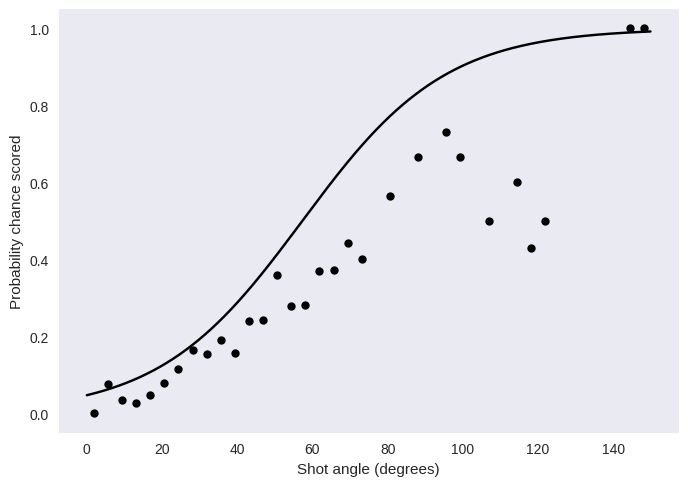

In [ ]:
fig, ax = plt.subplots()
b = [-3, 3]
x = np.arange(150,step=0.1)
y = 1/(1+np.exp(-(b[0]+b[1]*x*np.pi/180)))
#plot line
ax.plot(midangle, prob_goal, linestyle='none', marker= '.', markersize= 12, color='black')
#plot logistic function
ax.plot(x, y, linestyle='solid', color='black')
ax.set_ylabel('Probability chance scored')
ax.set_xlabel("Shot angle (degrees)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)
plt.show()

Fitted Intercept (b0): -3.5069
Fitted Angle Coefficient (b1): 2.8123


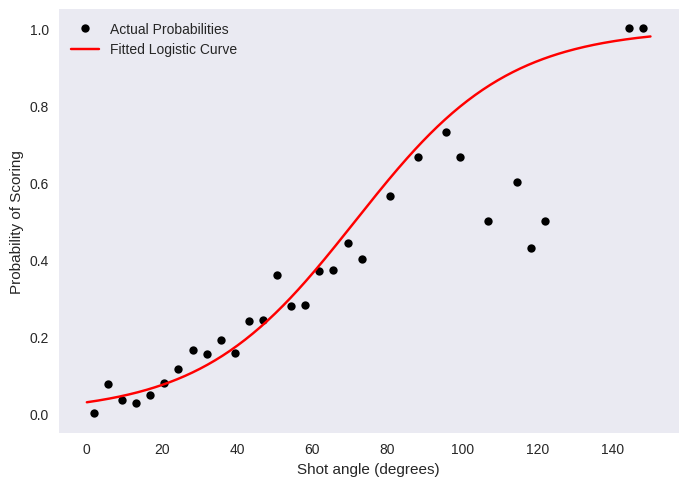

In [ ]:
import statsmodels.api as sm

X_logit = shots[['Angle']]
y_logit = shots['Goal']

# Fit the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_logit, y_logit)

# Extract the coefficients
b0_fitted = log_reg.intercept_[0]
b1_fitted = log_reg.coef_[0][0]

print(f"Fitted Intercept (b0): {b0_fitted:.4f}")
print(f"Fitted Angle Coefficient (b1): {b1_fitted:.4f}")

# Plotting the results
fig, ax = plt.subplots()

# Empirical data points from previous histograms
ax.plot(midangle, prob_goal, linestyle='none', marker='.', markersize=12, color='black', label='Actual Probabilities')

# Fitted Logistic Curve
x_range = np.linspace(0, 150, 300)
x_range_rad = x_range * np.pi / 180
y_fitted = 1 / (1 + np.exp(-(b0_fitted + b1_fitted * x_range_rad)))

ax.plot(x_range, y_fitted, linestyle='solid', color='red', label='Fitted Logistic Curve')

ax.set_ylabel('Probability of Scoring')
ax.set_xlabel('Shot angle (degrees)')
# ax.set_title('Logistic Regression: Angle vs Goal Probability')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)
plt.show()

## Modeling with distance

Fitted Intercept (b0): 0.1566
Fitted Angle Coefficient (b1): -0.1496


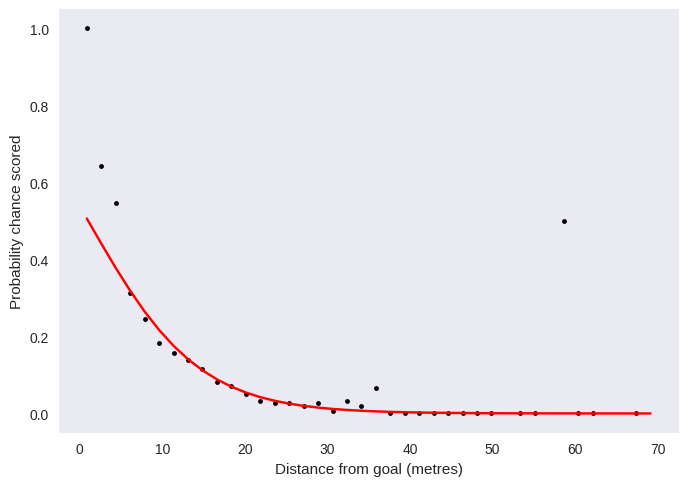

In [ ]:
#number of shots
shotcount_dist = np.histogram(shots['Distance'],bins=40,range=[0, 70])
#number of goals
goalcount_dist = np.histogram(goals['Distance'],bins=40,range=[0, 70])
#empirical probability of scoring
prob_goal = np.divide(goalcount_dist[0],shotcount_dist[0])
distance = shotcount_dist[1]
middistance= (distance[:-1] + distance[1:])/2
#making a plot
fig, ax = plt.subplots()
#plotting data
ax.plot(middistance, prob_goal, linestyle='none', marker= '.', color='black')
#making legend
ax.set_ylabel('Probability chance scored')
ax.set_xlabel("Distance from goal (metres)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


X_logit = shots[['Distance']]
y_logit = shots['Goal']

# Fit the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_logit, y_logit)

# Extract the coefficients
b0_fitted = log_reg.intercept_[0]
b1_fitted = log_reg.coef_[0][0]

print(f"Fitted Intercept (b0): {b0_fitted:.4f}")
print(f"Fitted Angle Coefficient (b1): {b1_fitted:.4f}")
#calculate xG
xGprob=1/(1+np.exp(-(b0_fitted+b1_fitted*middistance)))
#plot line
ax.plot(middistance, xGprob, linestyle='solid', color='red')
plt.grid(False)
plt.show()

In [ ]:
X_logit = shots[['Distance', 'Angle']]
y_logit = shots['Goal']

# Fit the logistic regression model
log_reg_multi = LogisticRegression()
log_reg_multi.fit(X_logit, y_logit)

# Extract the coefficients
b0 = log_reg_multi.intercept_[0]
b1 = log_reg_multi.coef_[0][0]
b2= log_reg_multi.coef_[0][1]

print(f"Fitted Intercept (b0): {b0:.4f}")
print(f"Fitted Distance Coefficient (b1): {b1:.4f}")
print(f"Fitted Angle Coefficient (b2): {b2:.4f}")

Fitted Intercept (b0): -1.1682
Fitted Distance Coefficient (b1): -0.0994
Fitted Angle Coefficient (b2): 1.1467


In [ ]:
def calculate_xG_model(distance, angle):
    logit = b0 + b1 * distance + b2 * angle
    return 1 / (1 + np.exp(-logit))

In [ ]:
pgoal_2d = np.zeros((68, 68))

for x in range(68):
    for y in range(68):

        # Horizontal distance from goal line
        X = x

        # Lateral distance from center of goal
        C = abs(y - 68/2)

        # Distance to goal
        distance = np.sqrt(X**2 + C**2)

        # Shot angle
        angle = np.arctan(7.32 * X / (X**2 + C**2 - (7.32/2)**2))
        if angle < 0:
            angle = np.pi + angle

        # Compute xG
        pgoal_2d[x, y] = calculate_xG_model(distance, angle)

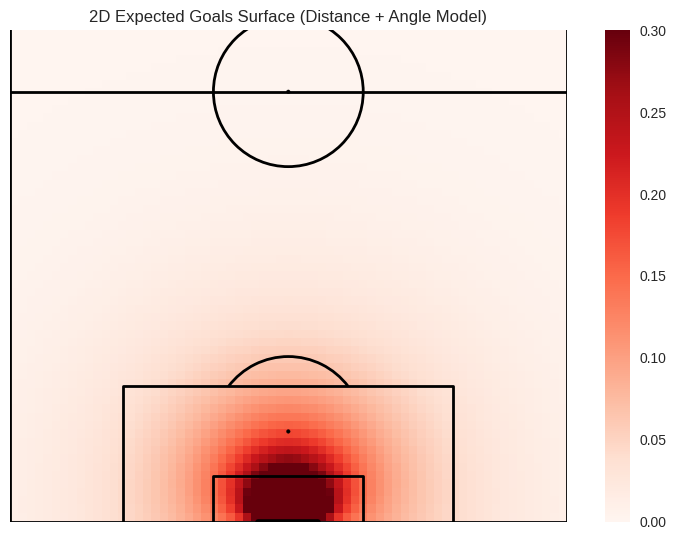

In [ ]:
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt

pitch = VerticalPitch(
    line_color='black',
    half=True,
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_zorder=2
)

fig, ax = pitch.draw()

pos = ax.imshow(
    pgoal_2d,
    extent=[-1, 68, 68, -1],
    aspect='auto',
    cmap=plt.cm.Reds,
    vmin=0,
    vmax=0.3,
    zorder=1
)

fig.colorbar(pos, ax=ax)
ax.set_title("2D Expected Goals Surface (Distance + Angle Model)")

plt.xlim((0, 68))
plt.ylim((0, 60))
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

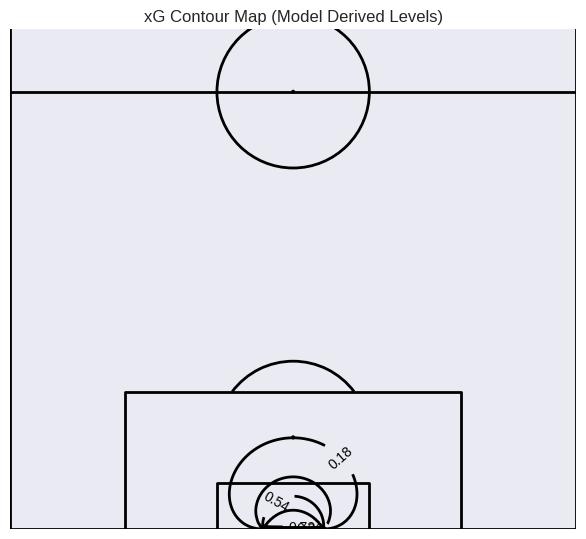

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch

# Increase resolution for smoother contours
nx, ny = 200, 200

x = np.linspace(0, 67, nx)
y = np.linspace(0, 67, ny)

X, Y = np.meshgrid(x, y)

# Compute xG surface directly using] fitted coefficients
distance = np.sqrt(X**2 + (Y - 68/2)**2)

angle = np.arctan(
    7.32 * X / (X**2 + (Y - 68/2)**2 - (7.32/2)**2)
)
angle[angle < 0] += np.pi

# Logistic model
logit = b0+ \
        b1* distance + \
        b2 * angle

pgoal_2d = 1 / (1 + np.exp(-logit))


pitch = VerticalPitch(
    line_color='black',
    half=True,
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_zorder=2
)

fig, ax = pitch.draw()

# Automatically choose contour levels from model surface
levels = np.linspace(
    np.min(pgoal_2d),
    np.max(pgoal_2d),
    6
)[1:-1]   # remove extreme min & max

contours = ax.contour(
    Y, X,
    pgoal_2d,
    levels=levels,
    colors='black',
    linewidths=2
)

ax.clabel(
    contours,
    fmt=lambda x: f"{x:.2f}",
    inline=True
)

ax.set_title("xG Contour Map (Model Derived Levels)")

plt.xlim(0, 68)
plt.ylim(0, 60)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

In [ ]:
y_pred_prob = log_reg_multi.predict_proba(X_logit)[:, 1]
y_true = y_logit.values

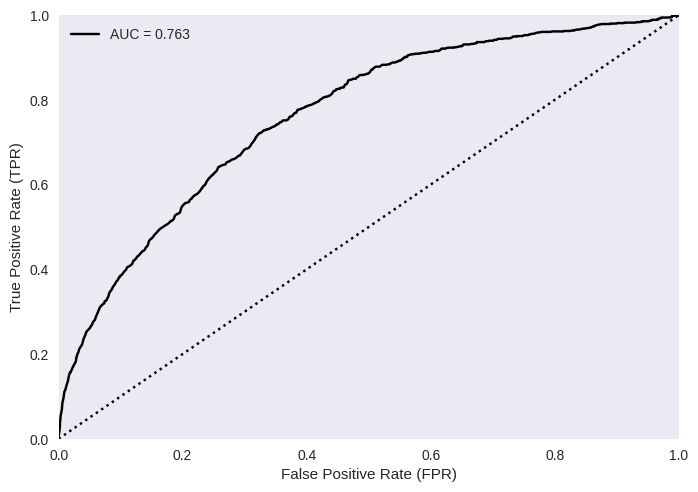

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()

ax.plot(fpr, tpr, color='black', label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle='dotted', color='black')

ax.set_ylabel("True Positive Rate (TPR)")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)
ax.legend()
plt.show()